## How are in-demand skills trending for Data Analysts?

#### Methology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
df = pd.read_csv('C:/Users/david/Desktop/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter
df = df[df['job_posted_date'].dt.year == 2024]

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DE_Ger = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

In [3]:
df_DE_Ger['job_posted_month_no'] = df_DE_Ger['job_posted_date'].dt.month

In [4]:
df_DE_Ger_explode = df_DE_Ger.explode('job_skills')

In [5]:
df_DE_Ger_pivot = df_DE_Ger_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DE_Ger_pivot.loc['Total'] = df_DE_Ger_pivot.sum()

df_DE_Ger_pivot = df_DE_Ger_pivot[df_DE_Ger_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_Ger_pivot = df_DE_Ger_pivot.drop('Total')

df_DE_Ger_pivot

job_skills,sql,python,excel,power bi,tableau,r,sap,azure,sas,aws,...,notion,theano,ggplot2,monday.com,mongo,spring,svn,blazor,aurora,digitalocean
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,244,203,135,134,108,95,51,30,38,15,...,0,0,0,1,1,1,0,0,1,0
2,262,237,149,149,120,93,74,37,42,34,...,1,1,0,0,0,0,0,1,0,0
3,248,217,112,118,103,94,46,45,22,30,...,0,0,0,0,0,0,0,0,0,0
4,186,152,100,84,71,59,43,37,16,23,...,0,0,1,0,0,0,0,0,0,0
5,212,151,90,95,101,74,53,35,20,15,...,0,0,0,0,0,0,1,0,0,1
6,196,162,112,109,85,71,50,30,44,12,...,0,0,0,0,0,0,0,0,0,0
7,209,166,94,123,97,63,61,27,22,23,...,0,0,0,0,0,0,0,0,0,0
8,126,23,62,28,22,0,59,0,0,31,...,0,0,0,0,0,0,0,0,0,0
9,65,15,44,15,12,0,37,0,0,20,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df_DE_Ger_totals = df_DE_Ger.groupby('job_posted_month_no').size()

df_DE_Ger_percentage = df_DE_Ger_pivot.div(df_DE_Ger_totals/100, axis=0)

df_DE_Ger_percentage = df_DE_Ger_percentage.reset_index()
df_DE_Ger_percentage['job_posted_month'] = df_DE_Ger_percentage['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DE_Ger_percentage = df_DE_Ger_percentage.drop('job_posted_month_no', axis=1)
df_DE_Ger_percentage = df_DE_Ger_percentage.set_index('job_posted_month')

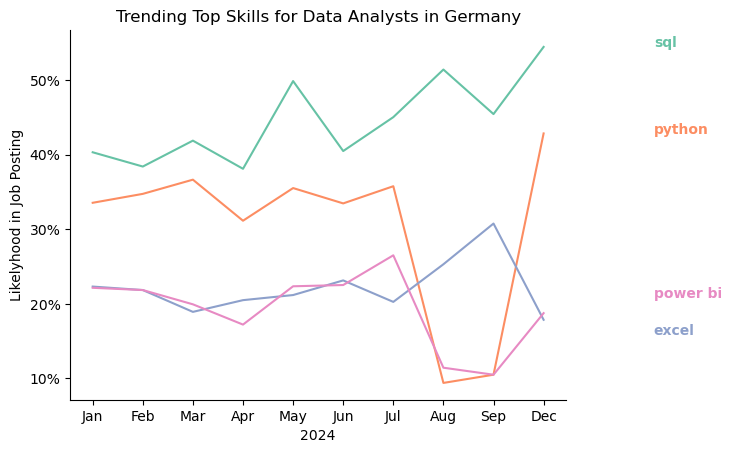

In [10]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DE_Ger_percentage.iloc[:,:4]
lineplot = sns.lineplot(df_plot, dashes=False, palette='Set2')
plt.title('Trending Top Skills for Data Analysts in Germany')
plt.ylabel('Likelyhood in Job Posting')
plt.xlabel('2024')
plt.legend().remove()
sns.despine()

ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

lines = lineplot.get_lines()

for i in range(4):
    col = df_plot.columns[i]
    y = df_plot.iloc[-1, i]

    line_color = lines[i].get_color()

    if col.lower() == "power bi":
        y = y + 2
    elif col.lower() == "excel":
        y = y - 2

    plt.text(11.2, y, col, color=line_color, fontweight='bold')

